In [71]:
import functions as f
import pandas as pd
import numpy as np

from 'function' I will use add_combinations and add_prev_days

I will check the model for following combinations:
- original data
- standarized
- without outliers
- with combinations
- with prev days
- with columns chosen only from random forest

# Upload data

In [72]:
X_train = pd.read_csv('data/to_model/X_train.csv')
X_valid = pd.read_csv('data/to_model/X_val.csv')
y_train = pd.read_csv('data/to_model/Y_train.csv')
y_valid = pd.read_csv('data/to_model/Y_val.csv')
X_train.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,windspeed,day_repaired_sin,day_repaired_cos,winddirection_sin,winddirection_cos
0,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,17.2,0.000000,1.000000,0.951057,0.309017
1,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,21.9,0.017261,0.999851,0.866025,0.500000
2,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,18.1,0.034516,0.999404,0.994522,0.104528
3,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,35.6,0.051761,0.998659,0.951057,0.309017
4,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,24.8,0.068991,0.997617,0.743145,0.669131


In [73]:
test = pd.read_csv('data/prev/test_prev.csv')
#wybieramy pierwsze 13 kolumn
X_test = test.iloc[:, :13]
X_test.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,windspeed,day_repaired_sin,day_repaired_cos,winddirection_sin,winddirection_cos
0,1019.5,17.5,15.8,12.7,14.9,96.0,99.0,0.0,24.3,0.017213,0.999852,0.866025,0.500000
1,1016.5,17.5,16.5,15.8,15.1,97.0,99.0,0.0,35.3,0.034422,0.999407,0.866025,0.500000
2,1023.9,11.2,10.4,9.4,8.9,86.0,96.0,0.0,16.9,0.051620,0.998667,0.743145,0.669131
3,1022.9,20.6,17.3,15.2,9.5,75.0,45.0,7.1,50.6,0.068802,0.997630,0.406737,0.913545
4,1022.2,16.1,13.8,6.4,4.3,68.0,49.0,9.2,19.4,0.085965,0.996298,0.406737,0.913545


# Make different data combinations

In [74]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

In [75]:
def standarize_data(data):
    scaler = StandardScaler()
    data_standardScaler = scaler.fit_transform(data)
    return pd.DataFrame(data_standardScaler, columns=data.columns)

In [76]:
def remove_outliers(X, y):
    iso_forest = IsolationForest(contamination=0.01, random_state=42)
    predictions = iso_forest.fit_predict(X)
    mask = predictions != -1
    X_cleaned = X[mask].reset_index(drop=True)
    y_cleaned = y[mask].reset_index(drop=True)
    return X_cleaned, y_cleaned

In [77]:
X_train_standard = standarize_data(X_train)
X_valid_standard = standarize_data(X_valid)

X_train_combinations = f.add_combinations(X_train)
X_valid_combinations = f.add_combinations(X_valid)

X_train_prev_days = f.add_prev_days(X_train)
X_valid_prev_days = f.add_prev_days(X_valid)

X_train_noOutliers, y_train_noOutliers = remove_outliers(X_train, y_train)
X_valid_noOutliers, y_valid_noOutliers = remove_outliers(X_valid, y_valid)

## feature selection

**PCA**

In [78]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

Explained variance ratio for each component: [0.35419031 0.17347794 0.08109169 0.04920634 0.03892322 0.03062276
 0.02807272 0.02524066 0.02300817 0.01995014 0.01932888 0.01880329
 0.01728433 0.01616988 0.01528456]
Total variance explained by the components: 0.9106549163956087
Transformed data (first 5 rows): 
[[-1.04414334e+01  4.97759960e+00 -4.83622944e+00 -3.54425037e+00
   3.07160262e+00 -2.36679428e-01  8.11531090e-01 -1.62340910e+00
  -2.32615710e+00 -7.00441891e-01  4.01491803e-01 -5.77459504e-01
  -6.19304621e-01 -2.30096358e-01  4.05232941e+00]
 [-1.93665227e+01  6.72640326e+00 -4.08904805e+00 -1.02756818e+00
   5.19596662e+00  3.53523505e+00  4.51002390e+00 -1.00916522e+00
  -2.06346667e+00 -1.95775945e+00  4.01505053e-01 -7.72969874e-01
   1.16110512e-02 -1.31281845e+00  4.56359962e+00]
 [-1.38107398e+01 -2.00279909e+01 -4.70794660e+00  4.32704078e-01
   2.80624405e+00 -3.70369473e+00  3.99876259e+00  6.86780736e-01
   1.71537428e+00 -3.69290554e-01  1.48757383e+00 -2.275074

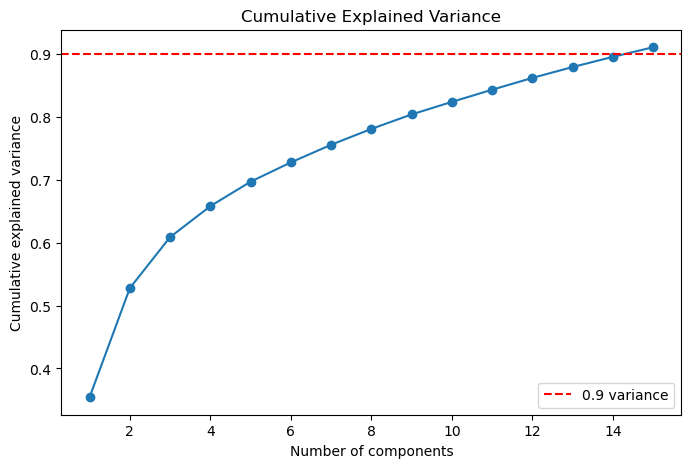

In [79]:
X = X_train_combinations

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

var = 0.9
pca = PCA(n_components=var)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance ratio for each component: {pca.explained_variance_ratio_}")
print(f"Total variance explained by the components: {sum(pca.explained_variance_ratio_)}")
print(f"Transformed data (first 5 rows): \n{X_pca[:5]}")

cum_var = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(cum_var) + 1), cum_var, marker='o')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.axhline(y=var, color='r', linestyle='--', label=f'{var} variance')
plt.legend()
plt.title("Cumulative Explained Variance")
plt.show()

In [80]:
n_components = np.argmax(cum_var >= 0.9) + 1
n_components

15

# Random Forest

In [81]:
from sklearn.ensemble import RandomForestClassifier

In [82]:
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train_combinations, y_train.values.reshape(-1))

importances = clf.feature_importances_
features_importance = pd.Series(importances, index=X_train_combinations.columns).sort_values(ascending=False)

print(features_importance)

day_repaired_cos_minus_cloud               0.033365
humidity_cloud_times                       0.031255
mintemp_cloud_plus                         0.024880
cloud_winddirection_sin_plus               0.022096
cloud_sunshine_plus                        0.021601
                                             ...   
winddirection_cos                          0.000356
temparature_winddirection_cos_plus         0.000307
winddirection_cos_div_winddirection_sin    0.000302
winddirection_sin                          0.000294
day_repaired_sin_minus_windspeed           0.000280
Length: 481, dtype: float64


In [83]:
df = features_importance.head(15).reset_index().rename(columns={"index": "Feature", 0: "Importance"})
df.index = range(1, 1 + len(df))
df

,Feature,Importance
1,day_repaired_cos_minus_cloud,0.033365
2,humidity_cloud_times,0.031255
3,mintemp_cloud_plus,0.024880
4,cloud_winddirection_sin_plus,0.022096
5,cloud_sunshine_plus,0.021601
6,cloud_minus_pressure,0.020565
7,temparature_cloud_plus,0.020243
8,winddirection_sin_minus_cloud,0.018488
9,maxtemp_cloud_plus,0.015573
10,day_repaired_sin_minus_cloud,0.014626


In [84]:
features = df['Feature'].tolist()
features

['day_repaired_cos_minus_cloud',
 'humidity_cloud_times',
 'mintemp_cloud_plus',
 'cloud_winddirection_sin_plus',
 'cloud_sunshine_plus',
 'cloud_minus_pressure',
 'temparature_cloud_plus',
 'winddirection_sin_minus_cloud',
 'maxtemp_cloud_plus',
 'day_repaired_sin_minus_cloud',
 'cloud_minus_day_repaired_cos',
 'pressure_minus_cloud',
 'cloud_day_repaired_sin_plus',
 'cloud_minus_temparature',
 'cloud_minus_sunshine']

In [85]:
X_train_rf = X_train_combinations[features]
X_valid_rf = X_valid_combinations[features]
X_train_rf.head()

,day_repaired_cos_minus_cloud,humidity_cloud_times,mintemp_cloud_plus,cloud_winddirection_sin_plus,cloud_sunshine_plus,cloud_minus_pressure,temparature_cloud_plus,winddirection_sin_minus_cloud,maxtemp_cloud_plus,day_repaired_sin_minus_cloud,cloud_minus_day_repaired_cos,pressure_minus_cloud,cloud_day_repaired_sin_plus,cloud_minus_temparature,cloud_minus_sunshine
0,-87.000000,7656.0,107.9,88.951057,89.1,-929.4,108.6,-87.048943,109.2,-88.000000,87.000000,929.4,88.000000,67.4,86.9
1,-90.000149,8645.0,106.8,91.866025,91.0,-928.5,107.9,-90.133975,107.2,-90.982739,90.000149,928.5,91.017261,74.1,91.0
2,-46.000596,3525.0,61.6,47.994522,55.3,-977.1,63.1,-46.005478,66.4,-46.965484,46.000596,977.1,47.034516,30.9,38.7
3,-94.001341,9025.0,111.9,95.951057,95.0,-918.4,112.8,-94.048943,113.1,-94.948239,94.001341,918.4,95.051761,77.2,95.0
4,-44.002383,2340.0,60.2,45.743145,48.6,-976.8,63.4,-44.256855,66.3,-44.931009,44.002383,976.8,45.068991,26.6,41.4


# Evaluation
all models will be evaluated on ROC AUC score

In [87]:
from sklearn.metrics import roc_auc_score
def evaluate_model(model, X_train, X_valid, y_train, y_valid):
    model.fit(X_train, y_train)
    y_pred = model.predict_proba(X_valid)[:,1]
    print(roc_auc_score(y_valid, y_pred))
    return roc_auc_score(y_valid, y_pred)

In [88]:
# def evaluate_model2(model, X_train, X_valid, y_train, y_valid):
#     model.fit(X_train, y_train)
#     y_pred = model.predict_proba(X_valid)[:, 1]
#     print(roc_auc_score(y_valid, y_pred))
#     return roc_auc_score(y_valid, y_pred)

# Model CatBoost

In [89]:
from catboost import CatBoostClassifier

In [90]:
y_train_r = y_train.values.reshape(-1)
y_valid_r = y_valid.values.reshape(-1)

In [91]:
categorical_features_indices = [i for i, col in enumerate(X_train.columns) if X_train[col].dtype == 'object']

model = CatBoostClassifier(
    iterations=600,
    learning_rate=0.05,
    depth=10,
    cat_features=categorical_features_indices,
    verbose=50
)

evaluate_model(model, X_train, X_valid, y_train_r, y_valid_r)

0:	learn: 0.6507227	total: 41.5ms	remaining: 24.9s
50:	learn: 0.2260601	total: 2.34s	remaining: 25.2s
100:	learn: 0.1583991	total: 4.71s	remaining: 23.3s
150:	learn: 0.1146552	total: 6.69s	remaining: 19.9s
200:	learn: 0.0858600	total: 8.43s	remaining: 16.7s
250:	learn: 0.0651931	total: 10.3s	remaining: 14.3s
300:	learn: 0.0521968	total: 12.1s	remaining: 12s
350:	learn: 0.0429110	total: 14.2s	remaining: 10.1s
400:	learn: 0.0350139	total: 15.8s	remaining: 7.82s
450:	learn: 0.0296236	total: 17.4s	remaining: 5.74s
500:	learn: 0.0257311	total: 19.4s	remaining: 3.83s
550:	learn: 0.0227045	total: 21.2s	remaining: 1.88s
599:	learn: 0.0201966	total: 23s	remaining: 0us
0.8791153556169893


0.8791153556169893

**Saving model**
it has the best score

In [62]:
pred1 = model.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    'id': 2190+ X_test.index,
    'target': pred1
})

print(submission.head())

     id    target
0  2190  0.999530
1  2191  0.999802
2  2192  0.992016
3  2193  0.012171
4  2194  0.001438


In [63]:
submission.to_csv('pred/pred_CatBoost.csv', index=False)

**Checking rest**

In [21]:
model = CatBoostClassifier(
    iterations=600,
    learning_rate=0.05,
    depth=6,
    cat_features=categorical_features_indices,
    verbose=50
)

evaluate_model(model, X_train_standard, X_valid_standard, y_train_r, y_valid_r)

0:	learn: 0.6531839	total: 3.35ms	remaining: 2.01s
50:	learn: 0.2919319	total: 178ms	remaining: 1.92s
100:	learn: 0.2548091	total: 347ms	remaining: 1.72s
150:	learn: 0.2251998	total: 529ms	remaining: 1.57s
200:	learn: 0.1928949	total: 695ms	remaining: 1.38s
250:	learn: 0.1674623	total: 860ms	remaining: 1.2s
300:	learn: 0.1447607	total: 1.03s	remaining: 1.02s
350:	learn: 0.1266974	total: 1.19s	remaining: 847ms
400:	learn: 0.1110595	total: 1.37s	remaining: 681ms
450:	learn: 0.0982540	total: 1.55s	remaining: 513ms
500:	learn: 0.0885201	total: 1.72s	remaining: 340ms
550:	learn: 0.0791340	total: 1.89s	remaining: 168ms
599:	learn: 0.0724036	total: 2.05s	remaining: 0us
0.8547687861271677


0.8547687861271677

In [49]:
model = CatBoostClassifier(
    iterations=600,
    learning_rate=0.05,
    depth=4,
    cat_features=categorical_features_indices,
    verbose=50
)

evaluate_model(model, X_train_combinations, X_valid_combinations, y_train_r, y_valid_r)

0:	learn: 0.6526463	total: 14.6ms	remaining: 8.77s
50:	learn: 0.3073691	total: 857ms	remaining: 9.22s
100:	learn: 0.2727324	total: 1.79s	remaining: 8.84s
150:	learn: 0.2478394	total: 2.69s	remaining: 7.99s
200:	learn: 0.2244224	total: 3.54s	remaining: 7.03s
250:	learn: 0.2038875	total: 4.47s	remaining: 6.21s
300:	learn: 0.1830906	total: 5.27s	remaining: 5.23s
350:	learn: 0.1672687	total: 6.14s	remaining: 4.35s
400:	learn: 0.1531343	total: 6.97s	remaining: 3.46s
450:	learn: 0.1393731	total: 7.82s	remaining: 2.58s
500:	learn: 0.1248972	total: 8.78s	remaining: 1.73s
550:	learn: 0.1122249	total: 9.65s	remaining: 859ms
599:	learn: 0.1028494	total: 10.5s	remaining: 0us
0.875848203066097


0.875848203066097

In [13]:
evaluate_model(model, X_train_noOutliers, X_valid_noOutliers, y_train, y_valid)

CatBoostError: Length of label=1752 and length of data=1734 is different.

In [46]:
model_rf = CatBoostClassifier(
    iterations=400,
    learning_rate=0.05,
    depth=2,
    cat_features=categorical_features_indices,
    verbose=50
)

evaluate_model(model_rf, X_train_rf, X_valid_rf, y_train_r, y_valid_r)

0:	learn: 0.6519332	total: 1.23ms	remaining: 490ms
50:	learn: 0.3432222	total: 80.8ms	remaining: 553ms
100:	learn: 0.3279190	total: 156ms	remaining: 462ms
150:	learn: 0.3176753	total: 235ms	remaining: 388ms
200:	learn: 0.3077310	total: 326ms	remaining: 322ms
250:	learn: 0.2993418	total: 407ms	remaining: 242ms
300:	learn: 0.2921912	total: 491ms	remaining: 161ms
350:	learn: 0.2855613	total: 568ms	remaining: 79.3ms
399:	learn: 0.2797717	total: 643ms	remaining: 0us
0.871638602663986


0.871638602663986

# MLP 

In [92]:
from sklearn.neural_network import MLPClassifier

In [133]:
y_train_ravel = y_train.to_numpy().ravel()
y_valid_ravel = y_valid.to_numpy().ravel()

In [142]:
mlp_model = MLPClassifier(hidden_layer_sizes=(100), max_iter=800, early_stopping=True)
evaluate_model(mlp_model, X_train, X_valid, y_train_ravel, y_valid_ravel)

0.8494910781603419


0.8494910781603419

In [108]:
mlp_model_standard = MLPClassifier(hidden_layer_sizes=(100,100), max_iter=1000, early_stopping=True)

evaluate_model(mlp_model_standard, X_train_standard, X_valid_standard, y_train_ravel, y_valid_ravel)

0.8550829354109073


0.8550829354109073

In [111]:
mlp_model_combinations = MLPClassifier(hidden_layer_sizes=(200,200), max_iter=1500, early_stopping=True)

evaluate_model(mlp_model_combinations, X_train_combinations, X_valid_combinations, y_train_ravel, y_valid_ravel)

0.7268000753958281


0.7268000753958281

In [112]:
mlp_models_rf = MLPClassifier(hidden_layer_sizes=(200,200), max_iter=1500, early_stopping=True) 

evaluate_model(mlp_models_rf, X_train_rf, X_valid_rf, y_train_ravel, y_valid_ravel)

0.8317573510932394


0.8317573510932394

# KNN model

In [186]:
from sklearn.neighbors import KNeighborsClassifier

In [199]:
knn_model = KNeighborsClassifier(n_neighbors=80, weights='distance')
evaluate_model(knn_model, X_train, X_valid, y_train_ravel, y_valid_ravel)

0.8812201558180449


0.8812201558180449

In [200]:
kk_model_standard = KNeighborsClassifier(n_neighbors=80, weights='distance')
evaluate_model(kk_model_standard, X_train_standard, X_valid_standard, y_train_ravel, y_valid_ravel)

0.8740575521487812


0.8740575521487812

In [205]:
knn_model_combinations = KNeighborsClassifier(n_neighbors=80, weights='distance')
evaluate_model(knn_model_combinations, X_train_combinations, X_valid_combinations, y_train_ravel, y_valid_ravel)

0.8850527770796682


0.8850527770796682

In [208]:
knn_model_rf = KNeighborsClassifier(n_neighbors=80, weights='distance')
evaluate_model(knn_model_rf, X_train_rf, X_valid_rf, y_train_ravel, y_valid_ravel)

0.8651985423473234


0.8651985423473234

In [211]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

neighbors_list = [5, 10, 20, 80]
weights_options = ['uniform', 'distance']
algorithms_options = ['auto', 'ball_tree', 'kd_tree', 'brute']
p_values = [1, 2]  # p=1 -> Manhattan, p=2 -> euklidesowa

best_score = 0
best_params = None
best_model = None

for n in neighbors_list:
    for w in weights_options:
        for alg in algorithms_options:
            for p in p_values:
                # Inicjalizacja modelu z aktualnymi parametrami
                model = KNeighborsClassifier(
                    n_neighbors=n,
                    weights=w,
                    algorithm=alg,
                    p=p,
                    n_jobs=-1 
                )
                # Trenowanie modelu
                model.fit(X_train, y_train_ravel)
                # Przewidywanie na zbiorze walidacyjnym
                y_pred = model.predict(X_valid)
                # Obliczanie accuracy
                score = accuracy_score(y_valid, y_pred)
                print(f"n_neighbors: {n}, weights: {w}, algorithm: {alg}, p: {p}, accuracy: {score:.4f}")

                # Zapamiętanie najlepszej konfiguracji
                if score > best_score:
                    best_score = score
                    best_params = (n, w, alg, p)
                    best_model = model

print("\nNajlepsze parametry:", best_params)
print("Najlepsza accuracy:", best_score)

n_neighbors: 5, weights: uniform, algorithm: auto, p: 1, accuracy: 0.8630
n_neighbors: 5, weights: uniform, algorithm: auto, p: 2, accuracy: 0.8767
n_neighbors: 5, weights: uniform, algorithm: ball_tree, p: 1, accuracy: 0.8630
n_neighbors: 5, weights: uniform, algorithm: ball_tree, p: 2, accuracy: 0.8767
n_neighbors: 5, weights: uniform, algorithm: kd_tree, p: 1, accuracy: 0.8630
n_neighbors: 5, weights: uniform, algorithm: kd_tree, p: 2, accuracy: 0.8767
n_neighbors: 5, weights: uniform, algorithm: brute, p: 1, accuracy: 0.8630
n_neighbors: 5, weights: uniform, algorithm: brute, p: 2, accuracy: 0.8767
n_neighbors: 5, weights: distance, algorithm: auto, p: 1, accuracy: 0.8630
n_neighbors: 5, weights: distance, algorithm: auto, p: 2, accuracy: 0.8767
n_neighbors: 5, weights: distance, algorithm: ball_tree, p: 1, accuracy: 0.8630
n_neighbors: 5, weights: distance, algorithm: ball_tree, p: 2, accuracy: 0.8767
n_neighbors: 5, weights: distance, algorithm: kd_tree, p: 1, accuracy: 0.8630
n_

**Saving pred**

In [212]:
pred_knn = best_model.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    'id': 2190+ X_test.index,
    'target': pred_knn
})

print(submission.head())

     id  target
0  2190    1.00
1  2191    1.00
2  2192    0.90
3  2193    0.25
4  2194    0.15


In [213]:
submission.to_csv('pred/pred_knn.csv', index=False)

**Other data**

In [210]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

neighbors_list = [5, 10, 20, 80]
weights_options = ['uniform', 'distance']
algorithms_options = ['auto', 'ball_tree', 'kd_tree', 'brute']
p_values = [1, 2]  # p=1 -> Manhattan, p=2 -> euklidesowa

best_score = 0
best_params = None

for n in neighbors_list:
    for w in weights_options:
        for alg in algorithms_options:
            for p in p_values:
                # Inicjalizacja modelu z aktualnymi parametrami
                model = KNeighborsClassifier(
                    n_neighbors=n,
                    weights=w,
                    algorithm=alg,
                    p=p,
                    n_jobs=-1 
                )
                # Trenowanie modelu
                model.fit(X_train_combinations, y_train_ravel)
                # Przewidywanie na zbiorze walidacyjnym
                y_pred = model.predict(X_valid_combinations)
                # Obliczanie accuracy
                score = accuracy_score(y_valid, y_pred)
                print(f"n_neighbors: {n}, weights: {w}, algorithm: {alg}, p: {p}, accuracy: {score:.4f}")

                # Zapamiętanie najlepszej konfiguracji
                if score > best_score:
                    best_score = score
                    best_params = (n, w, alg, p)

print("\nNajlepsze parametry:", best_params)
print("Najlepsza accuracy:", best_score)


n_neighbors: 5, weights: uniform, algorithm: auto, p: 1, accuracy: 0.8562
n_neighbors: 5, weights: uniform, algorithm: auto, p: 2, accuracy: 0.8653
n_neighbors: 5, weights: uniform, algorithm: ball_tree, p: 1, accuracy: 0.8562
n_neighbors: 5, weights: uniform, algorithm: ball_tree, p: 2, accuracy: 0.8653
n_neighbors: 5, weights: uniform, algorithm: kd_tree, p: 1, accuracy: 0.8562
n_neighbors: 5, weights: uniform, algorithm: kd_tree, p: 2, accuracy: 0.8653
n_neighbors: 5, weights: uniform, algorithm: brute, p: 1, accuracy: 0.8562
n_neighbors: 5, weights: uniform, algorithm: brute, p: 2, accuracy: 0.8653
n_neighbors: 5, weights: distance, algorithm: auto, p: 1, accuracy: 0.8562
n_neighbors: 5, weights: distance, algorithm: auto, p: 2, accuracy: 0.8653
n_neighbors: 5, weights: distance, algorithm: ball_tree, p: 1, accuracy: 0.8562
n_neighbors: 5, weights: distance, algorithm: ball_tree, p: 2, accuracy: 0.8653
n_neighbors: 5, weights: distance, algorithm: kd_tree, p: 1, accuracy: 0.8562
n_

# AdaBoostClassifier

In [114]:
from sklearn.ensemble import AdaBoostClassifier

In [158]:
ada_model = AdaBoostClassifier(n_estimators=400, learning_rate=0.05)

evaluate_model(ada_model, X_train, X_valid, y_train_ravel, y_valid_ravel)

0.8833092485549133


0.8833092485549133

In [150]:
ada_model_standard = AdaBoostClassifier(n_estimators=300, learning_rate=0.05)
evaluate_model(ada_model_standard, X_train_standard, X_valid_standard, y_train_ravel, y_valid_ravel)

0.8760052777079668


0.8760052777079668

In [152]:
ada_model_combinations = AdaBoostClassifier(n_estimators=300, learning_rate=0.1)
evaluate_model(ada_model_combinations, X_train_combinations, X_valid_combinations, y_train_ravel, y_valid_ravel)

0.874136089469716


0.874136089469716

In [160]:
ada_model_rf = AdaBoostClassifier(n_estimators=300, learning_rate=0.05)
evaluate_model(ada_model_rf, X_train_rf, X_valid_rf, y_train_ravel, y_valid_ravel)

0.8742303342548379


0.8742303342548379

Best score is for original data, let's check other parameters

In [175]:
from sklearn.tree import DecisionTreeClassifier

ada_model2 = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2),
    n_estimators=600,
    learning_rate=0.05,
    #algorithm='SAMME',
    random_state=42
)

evaluate_model(ada_model2, X_train, X_valid, y_train_ravel, y_valid_ravel)

0.8907545865795425


0.8907545865795425

**Saving pred**

In [176]:
pred_ada = ada_model.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    'id': 2190+ X_test.index,
    'target': pred_ada
})

print(submission.head())

     id    target
0  2190  0.863135
1  2191  0.863135
2  2192  0.805215
3  2193  0.369828
4  2194  0.299119


In [177]:
submission.to_csv('pred/pred_AdaBoost.csv', index=False)

# Gaussian Naive Bayes

In [178]:
from sklearn.naive_bayes import GaussianNB

In [181]:
gnb = GaussianNB(priors=None, var_smoothing=1e-8)
evaluate_model(gnb, X_train, X_valid, y_train_ravel, y_valid_ravel)

0.8776074390550389


0.8776074390550389

In [182]:
gnb_standard = GaussianNB(priors=None, var_smoothing=1e-8)
evaluate_model(gnb_standard, X_train_standard, X_valid_standard, y_train_ravel, y_valid_ravel)

0.8780786629806484


0.8780786629806484

In [183]:
gnb_combinations = GaussianNB(priors=None, var_smoothing=1e-8)
evaluate_model(gnb_combinations, X_train_combinations, X_valid_combinations, y_train_ravel, y_valid_ravel)

0.5086705202312138


0.5086705202312138

In [184]:
gnb_rf = GaussianNB(priors=None, var_smoothing=1e-8)
evaluate_model(gnb_rf, X_train_rf, X_valid_rf, y_train_ravel, y_valid_ravel)

0.8819898215632067


0.8819898215632067